# Read UK radar data from cloud-hosted .h5 file 

**Launch this notebook:**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Thomasjkeel/access-UK-radar-data/blob/main/from_cloud/read_radar_data_from_open_data_registry.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/Thomasjkeel/access-UK-radar-data/HEAD)

---

**Setup**
Let's load the python libraries we need to read this data.  
If required, you can install required packages by uncommenting and running the cell below...

In [1]:
# %%capture
# !pip install xarray[io] cartopy boto3 geopandas numpy pyproj s3fs rasterio matplotlib

In [1]:
# Python standard libraries
import datetime
import itertools
from pathlib import Path

# 3rd party libraries
import boto3
import geopandas as gpd
import numpy as np
import pyproj
import rioxarray
import s3fs
import xarray as xr

import cartopy.crs as ccrs
import matplotlib.pyplot as plt

from botocore import UNSIGNED
from botocore.config import Config

# Introduction
In this example, we will use the AWS SDK, boto3, to read 15 min composite UK radar data from the [OpenDataRegistry](https://registry.opendata.aws/met-office-uk-radar-observations/), you can think of this as "loading data from the cloud".
The Open Data Registry stores data on a 2-year rolling window, so depending on when you run through this example, the data may no longer be available.

## Gallery (visualisations from this notebook)
<p float="left">
    <img src="https://raw.githubusercontent.com/Thomasjkeel/access-UK-radar-data/refs/heads/main/figures/UK_rain_from_radar_15min_aws.png" alt="15min-mean" style="width:250px;"/>
</p>

<p float="left">
    <img src="https://raw.githubusercontent.com/Thomasjkeel/access-UK-radar-data/refs/heads/main/figures/severn_catchment_subset_15min_aws.png" alt="catch-subset" style="width:500px;"/>  
</p>

<p float="left">
    <img src="https://raw.githubusercontent.com/Thomasjkeel/access-UK-radar-data/refs/heads/main/figures/catchment_mean_rainfall_aws.png" alt="catch-subset" style="width:500px;" />
</p>


### Table of contents
1. Set up AWS S3 reader
2. Load h5 data
3. Reproject data
4. Load multiple radar timesteps into one dataset
5. Subset data to river catchment boundary 

# 1. Set up AWS S3 reader
Let's use boto3 to read data for July 2026 from an s3 bucket "met-office-radar-obs-data".  
*Note: this data is available on a two-year rolling window, so please update the `prefix` if 2026/07/ is no longer available*

In [2]:
# Define which s3 bucket the data is in, and the name of the h5 files
bucket_name = "met-office-radar-obs-data"
date_prefix = "radar/2026/07/"
search_term = "radar_rainrate_composite"

# Create an S3 client with unsigned (anonymous) access
s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))

In [3]:
# List the prefixes
response = s3.list_objects_v2(
    Bucket=bucket_name,
    Prefix=date_prefix,
    Delimiter="/"
)

In [4]:
# select the prefix dirs, this makes the search for files a lot quicker
prefix_dirs = []
for common_prefix in response.get('CommonPrefixes', []):
    prefix_dirs.append(common_prefix['Prefix'])

In [5]:
response.get('CommonPrefixes', [])[0]['Prefix']

'radar/2026/07/01/'

In [6]:
# Make an anonymous connection to S3 bucket filesystem
fs = s3fs.S3FileSystem(anon=True)

Should be 96 files for the 15 min time steps

In [7]:
# search files for data we want for our chosen data
files = fs.glob(f"{bucket_name}/{date_prefix}01/*{search_term}*.h5") 

In [8]:
len(files)

96

In [9]:
files[:5]

['met-office-radar-obs-data/radar/2026/07/01/202607010000_ODIM_ng_radar_rainrate_composite_1km_UK.h5',
 'met-office-radar-obs-data/radar/2026/07/01/202607010015_ODIM_ng_radar_rainrate_composite_1km_UK.h5',
 'met-office-radar-obs-data/radar/2026/07/01/202607010030_ODIM_ng_radar_rainrate_composite_1km_UK.h5',
 'met-office-radar-obs-data/radar/2026/07/01/202607010045_ODIM_ng_radar_rainrate_composite_1km_UK.h5',
 'met-office-radar-obs-data/radar/2026/07/01/202607010100_ODIM_ng_radar_rainrate_composite_1km_UK.h5']

# 2. Load h5 data
Now that we have a connection to the data within the s3 bucket, let's load the data in locally. The data files are in [Hierachical Data Format](https://en.wikipedia.org/wiki/Hierarchical_Data_Format) (h5) which can be opened as a [DataTree](https://docs.xarray.dev/en/stable/generated/xarray.DataTree.html) with xarray.

In [10]:
def hdf5_loader(filepath):
    f = fs.open(filepath)
    datatree = xr.open_datatree(f, engine="h5netcdf", phony_dims='sort')
    return datatree

In [11]:
datatree = hdf5_loader(files[23]) # load the 23 file

In [12]:
datatree

<xarray.DataTree>
Group: /
│   Attributes:
│       Conventions:  ODIM_H5/V2_2
├── Group: /dataset1
│   ├── Group: /dataset1/data1
│   │   │   Dimensions:  (phony_dim_0: 2175, phony_dim_1: 1725)
│   │   │   Dimensions without coordinates: phony_dim_0, phony_dim_1
│   │   │   Data variables:
│   │   │       data     (phony_dim_0, phony_dim_1) float32 15MB ...
│   │   └── Group: /dataset1/data1/what
│   │           Attributes:
│   │               gain:      1.0
│   │               nodata:    -1.0
│   │               offset:    0.0
│   │               quantity:  RATE
│   │               undetect:  0.0
│   ├── Group: /dataset1/how
│   │       Attributes:
│   │           origin:   UPPER LEFT
│   └── Group: /dataset1/what
│           Attributes:
│               enddate:    20260701
│               endtime:    054509
│               product:    COMP
│               startdate:  20260701
│               starttime:  054407
├── Group: /how
│       Attributes:
│           VPRCorr:      True
│           camethod:     DOMAIN
│           endepochs:    1782884709
│           nodes:        ukcle,ukham,ukche,iesha,ukcas,ukpre,uking,ukcyg,ukjer,ukdud...
│           simulated:    False
│           software:     RADARNET
│           startepochs:  1782884647
│           sw_version:   2021.11.0
│           task:         MO.UK.RADARNET.PCompMulti
│           zr_a:         200.0
│           zr_b:         1.6
├── Group: /what
│       Attributes:
│           date:     20260701
│           object:   COMP
│           source:   WMO:03523,WMO:03331,WMO:03675,WMO:03962,WMO:03918,WMO:03813,WMO...
│           time:     054500
│           version:  H5rad 2.2
└── Group: /where
        Attributes: (12/13)
            LL_lat:   43.83405184575088
            LL_lon:   -12.011794919778003
            LR_lat:   43.70087658067965
            LR_lon:   9.415780820163617
            UL_lat:   62.92071695962483
            UL_lon:   -17.973932221553792
            ...       ...
            UR_lon:   16.128870790695817
            projdef:  +proj=tmerc +lat_0=49 +lon_0=-2 +k=0.999601 +x_0=400000 +y_0=-1...
            xscale:   1000.0
            xsize:    1725
            yscale:   1000.0
            ysize:    2175

Hmm, that's a weird format. Let's look at the attributes under 'where' to see the timestamp

In [13]:
data_attrs = datatree['where'].attrs

In [14]:
datatree['dataset1/what'].attrs

{'enddate': '20260701',
 'endtime': '054509',
 'product': 'COMP',
 'startdate': '20260701',
 'starttime': '054407'}

Because these are from Radar scans, the scan has a start and endtime, but that does not always fall exactly on a 15-min periodicity. To fix that, let's use the following function to round each time step to the nearest 15 min...

In [15]:
def round_to_nearest_n_mins(time_str, n_mins):
    """Takes an input of time (in str format), and rounds to nearest n_mins."""
    t = datetime.datetime.strptime(time_str, "%H%M%S")
    total_minutes = t.hour * 60 + t.minute + t.second / 60
    rounded_minutes = round(total_minutes / n_mins) * n_mins
    rounded_minutes %= (24 * 60)  # wrap around midnight
    h, m = divmod(int(rounded_minutes), 60)
    return f"{h:02d}{m:02d}00"

In [16]:
# Let's test that function
round_to_nearest_n_mins(datatree['dataset1/what'].attrs['endtime'], n_mins=15)

'054500'

Now that we know that function works, let's have it applied to those time attribute of the datatree. We'll do that with the following function...

In [17]:
def round_datetime_from_attrs(data, n_mins):
    """Round datetime string from enddate attribute of a datatree."""
    rounded_datetime = data.attrs['enddate'] + '-' + round_to_nearest_n_mins(data.attrs['endtime'], n_mins=n_mins)
    rounded_datetime = datetime.datetime.strptime(rounded_datetime, '%Y%m%d-%H%M%S')
    return rounded_datetime

In [18]:
rounded_datetime = round_datetime_from_attrs(datatree['dataset1/what'], n_mins=15)

In [19]:
rounded_datetime

datetime.datetime(2026, 7, 1, 5, 45)

# 3. Reproject data
So that we can compare this data to other UK-based dataset, we will reprojected with `pyproj` to British National Grid (crs=27700)...

In [20]:
crs_bng = pyproj.CRS.from_proj4(data_attrs['projdef'])
crs_wgs84 = pyproj.CRS.from_epsg(4326)
transformer = pyproj.Transformer.from_crs(crs_wgs84, crs_bng, always_xy=True)

In [21]:
def set_coords_based_on_data_attrs(data, data_attrs):
    """Set x, y coordinates based on data attributes of DataTree."""
    # Project the corner coordinates
    LR_x, LR_y = transformer.transform(data_attrs['LR_lon'], data_attrs['LR_lat'])
    UL_x, UL_y = transformer.transform(data_attrs['UL_lon'], data_attrs['UL_lat'])

    x0 = LR_x - (data_attrs['xsize'] - 1) * data_attrs['xscale']
    y0 = LR_y
    x = x0 + np.arange(data_attrs['xsize']) * data_attrs['xscale']
    y = y0 + np.arange(data_attrs['ysize']) * data_attrs['yscale']
    
    # the y axis is flipped
    y = sorted(y, reverse=True)

    data = data.assign_coords({
        "x": ("phony_dim_1", x),
        "y": ("phony_dim_0", y)
    })

    data = data.swap_dims({
        "phony_dim_0": "y",
        "phony_dim_1": "x",
    })
    return data

Let's convert the datatree to a dataset, and set x and y coords based on attributes 

In [22]:
radar_1d = datatree['dataset1/data1'].to_dataset()
radar_1d['time'] = rounded_datetime

radar_1d = set_coords_based_on_data_attrs(radar_1d, data_attrs)

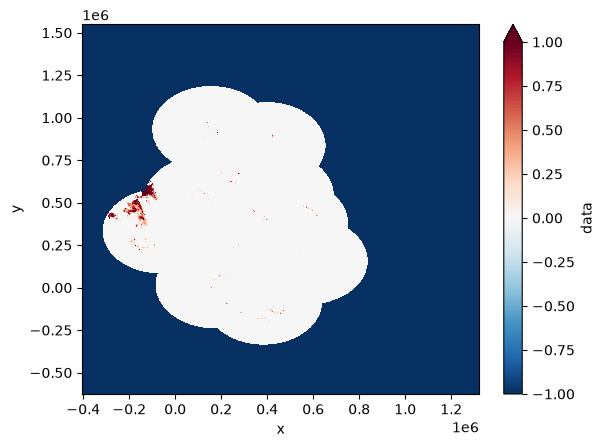

In [23]:
radar_1d['data'].plot(vmin=-1)

In [24]:
# Define British National Grid projection for plotting
bng = ccrs.TransverseMercator(
    central_longitude=-2.0,  ## +lon_0
    central_latitude=49.0,      # +lat_0
    scale_factor=0.999601,      # +k
    false_easting=400000.0,     # +x_0
    false_northing=-100000.0,   # +y_0
    globe=ccrs.Globe(ellipse='airy')  # +ellps=airy
)

In [25]:
date_time_to_examine = str(radar_1d['time'].dt.strftime("%Y-%m-%d %H:%M").values)
print(date_time_to_examine) #  reminder of date we are plotting

2026-07-01 05:45


Text(0.38, 0.28, 'Composite radar (from OpenDataRegistry)')

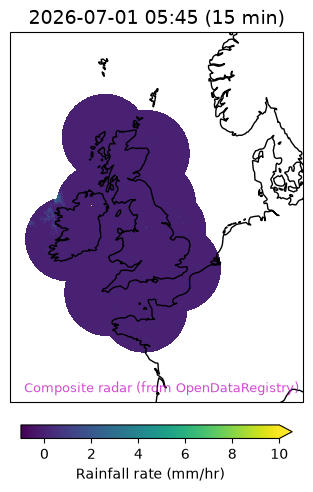

In [26]:
fig, ax = plt.subplots(1, subplot_kw={'projection': bng}, figsize=(10, 6))
radar_1d['data'].where(lambda data: data >= 0).plot(
    vmin=-1, vmax=10, ax=ax, 
    add_colorbar=True, cbar_kwargs={'orientation': 'horizontal', 'shrink': 0.35, 'pad': 0.05, 'label': 'Rainfall rate (mm/hr)'},
    transform=bng)
ax.coastlines();
ax.set_title(f"{date_time_to_examine} (15 min)", size=14);
fig.text(s="Composite radar (from OpenDataRegistry)",size=9, x=.38, y=.28, c='m', alpha=.7)
# fig.savefig("../../figures/UK_rain_from_radar_15min_aws.png", bbox_inches='tight', dpi=150)

# 4. Load multiple radar timesteps into one dataset
Now that we have loaded a single 15 min step, we will repeat this to load in 5 days of data from the cloud.

In [27]:
# reminder of where we are getting the data from
print(bucket_name, date_prefix, search_term)

met-office-radar-obs-data radar/2026/07/ radar_rainrate_composite


In [28]:
month_files = fs.glob(f"{bucket_name}/{date_prefix}*/*{search_term}*.h5") 

In [29]:
five_day_files = month_files[:96*5]

In [30]:
len(five_day_files)

480

In [31]:
# Place to store the output
ZARR_OUTPUT_PATH = Path("output/radar.zarr")
BATCH_SIZE = 200

In [32]:
# batch saving, as to not create out of memory errors
def batch(iterable, n):
    it = iter(iterable)
    while chunk := list(itertools.islice(it, n)):
        yield chunk

We'll have to use the below function to round the x and y coordinates so that they are the same format as the GeoTIFF file loaded later...

In [33]:
def shift_data_by_offset(radar_1d, var_name, shift_in_m):
    dx = shift_in_m
    dy = shift_in_m

    new_x = np.round(radar_1d['x']) + dx
    new_y = np.round(radar_1d['y']) + dy
    
    radar_1d = radar_1d.rio.write_crs("epsg:27700")

    shifted_radar = radar_1d.interp(x=new_x, y=new_y)
    shifted_radar = shifted_radar.assign_coords(x=new_x)
    shifted_radar = shifted_radar.assign_coords(y=new_y)
    shifted_radar[var_name] = shifted_radar[var_name].fillna(-1.)
    return shifted_radar



In [34]:
%%time
# Takes ~5 mins (timing is resource-dependent)
first_write = True

for batch_num, batch_files in enumerate(batch(five_day_files[:], BATCH_SIZE)):
    print(f"Batch {batch_num} — files {batch_num * BATCH_SIZE} to {batch_num * BATCH_SIZE + len(batch_files) - 1}")
    batch_results = []

    for ind, file in enumerate(batch_files):
        datatree = hdf5_loader(file)
        rounded_datetime = round_datetime_from_attrs(datatree['dataset1/what'], n_mins=15)
        one_radar = datatree['dataset1/data1'].to_dataset()
        one_radar['time'] = rounded_datetime
        one_radar = one_radar.set_coords('time')
        one_radar = set_coords_based_on_data_attrs(one_radar, data_attrs)
        one_radar = one_radar.sel(y=slice(1200000, -340000), x=slice(-320000, 848000))
        one_radar_shifted = shift_data_by_offset(one_radar, var_name='data', shift_in_m=0)
        batch_results.append(one_radar_shifted)

    batch_ds = xr.concat(batch_results, dim="time")
    del batch_results

    if first_write:
        batch_ds.to_zarr(ZARR_OUTPUT_PATH, mode="w", zarr_format=2)
        first_write = False
    else:
        batch_ds.to_zarr(ZARR_OUTPUT_PATH, append_dim="time", zarr_format=2)

    del batch_ds
    print(f"  Written batch {batch_num}")



Batch 0 — files 0 to 199
  Written batch 0
Batch 1 — files 200 to 399
  Written batch 1
Batch 2 — files 400 to 479
  Written batch 2
CPU times: user 3min 20s, sys: 36.8 s, total: 3min 56s
Wall time: 4min 20s


In [35]:
combined_radar_ds = xr.open_zarr(ZARR_OUTPUT_PATH)

In [36]:
combined_radar_ds

<xarray.Dataset> Size: 7GB
Dimensions:      (time: 480, y: 1540, x: 1168)
Coordinates:
  * time         (time) datetime64[ns] 4kB 2026-06-30 ... 2026-07-05T23:45:00
  * y            (y) float64 12kB 1.2e+06 1.199e+06 ... -3.38e+05 -3.39e+05
  * x            (x) float64 9kB -3.19e+05 -3.18e+05 ... 8.47e+05 8.48e+05
    spatial_ref  int64 8B ...
Data variables:
    data         (time, y, x) float64 7GB dask.array<chunksize=(13, 193, 146), meta=np.ndarray>

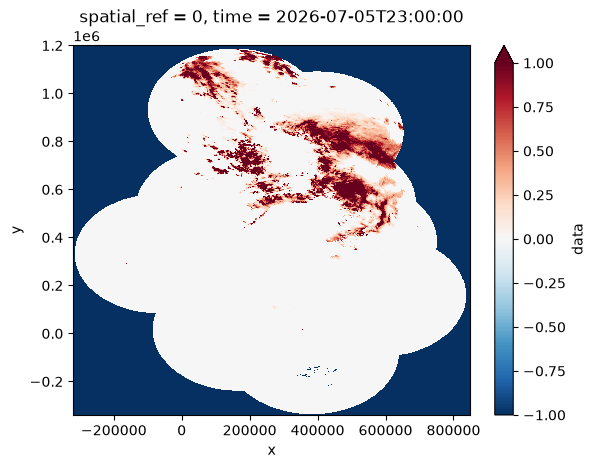

In [37]:
combined_radar_ds['data'].isel(time=-4).plot(vmin=-1)

In [38]:
# Save outputs if you want to use them...
# combined_radar = xr.concat(combined_radar_ls, dim='time')

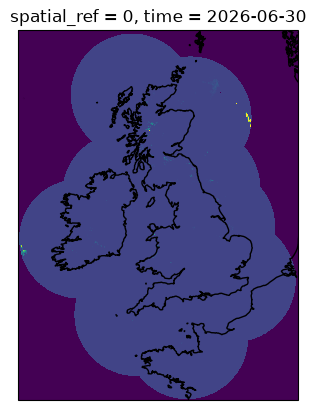

In [39]:
fig, ax = plt.subplots(1, subplot_kw={'projection': bng})
combined_radar_ds.isel(time=0)['data'].plot(vmin=-1, vmax=4, ax=ax, add_colorbar=False, transform=bng)
ax.coastlines()

90 time steps == 60 MB 

# 5. Subset to a river catchment
Because the data is in xarray format, we can mask out regions of it. Let's mask out a river catchment.

We'll use catchment boundary data from the National River Flow Archive ([NRFA](https://nrfa.ceh.ac.uk/)). Specifically, this example comes with a catchment boundary of the Severn at Haw Bridge ([ID: 54057](https://nrfa.ceh.ac.uk/data/station/info/54057)). 

In this next section, we are working with Shapefiles of catchment boundaries, which cannot be directly loaded into xarray, so we'll use a GeoTIFF file and the library [rasterio](https://corteva.github.io/rioxarray/stable/index.html) to leverage [rasterio](https://rasterio.readthedocs.io/en/latest/index.html) to create a 1km by 1km mask.

### Load in catchment boundary

In [40]:
# we'll use a buffer so the subset is not too tight to the boundary
CATCHMENT_BUFFER = 1500 # metres

In [41]:
# Read in catchment boundary for the River Severn at Haw Bridge
nrfa_shp = gpd.read_file("../../spatial_data/nrfa_54057/NRFA_catchments.shp")
print(nrfa_shp.bounds)

       minx      miny      maxx      maxy
0  281525.0  221825.0  469475.0  342725.0


<Axes: >

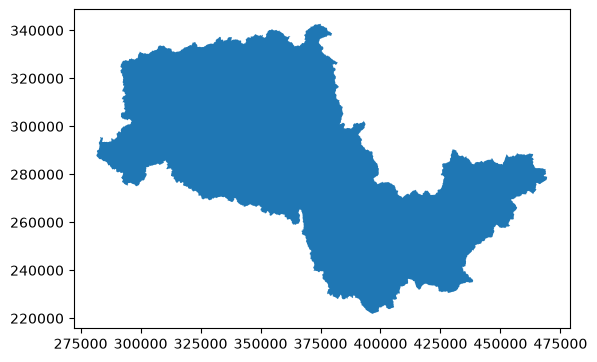

In [42]:
nrfa_shp.plot()

### Clip data to catchment bounds
To save memory, and compute time, we'll reduce the size of the radar composite to the bounds of the catchment boundary...

*NOTE: For the code below, some other data may not have a descending y-axis. Please check your data*

In [43]:
# Subset to bounds of given catchment 
catchment_radar_ds = combined_radar_ds.sel(
    x=slice(nrfa_shp.bounds['minx'][0]-CATCHMENT_BUFFER, nrfa_shp.bounds['maxx'][0]+CATCHMENT_BUFFER),
    y=slice(nrfa_shp.bounds['maxy'][0]+CATCHMENT_BUFFER, nrfa_shp.bounds['miny'][0]-CATCHMENT_BUFFER), # has to be reversed as y coordinates is descending
)
catchment_radar_ds = catchment_radar_ds.sortby("y")  # flip y coordinates


In [44]:
catchment_radar_ds

<xarray.Dataset> Size: 90MB
Dimensions:      (time: 480, y: 124, x: 190)
Coordinates:
  * time         (time) datetime64[ns] 4kB 2026-06-30 ... 2026-07-05T23:45:00
  * y            (y) float64 992B 2.21e+05 2.22e+05 ... 3.43e+05 3.44e+05
  * x            (x) float64 2kB 2.81e+05 2.82e+05 2.83e+05 ... 4.69e+05 4.7e+05
    spatial_ref  int64 8B ...
Data variables:
    data         (time, y, x) float64 90MB dask.array<chunksize=(13, 62, 130), meta=np.ndarray>

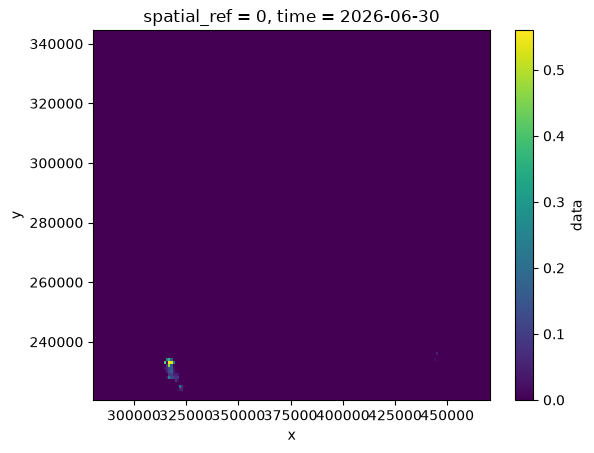

In [46]:
# plot out a single time step
catchment_radar_ds.isel(time=0)['data'].plot()

### Clip the radar field based on the catchment boundary GeoTIFF
We'll introduce 2 small functions to clip the GeoTIFF based on the catchment boundary shapefile. 

In [47]:
def make_region_hght_clip(region_shp, hght_data):
    """Clip region by height raster"""
    region_clip = hght_data.rio.clip(
        region_shp.geometry.values, region_shp.crs, drop=False, invert=False
    )
    return region_clip


def binarize_hght_clip(region_data):
    """
    Make binary mask of clipped region data data
    """
    return region_data / region_data.where(region_data > 0)

In [48]:
# Load in a 1 km UK-wide GeoTIFF (in this case it is height data)
uk_hght = rioxarray.open_rasterio("../../spatial_data/uk_cehgear_mask.tif")

In [49]:
# Make catchment mask, and clip that catchment mask to the same bounds as the radar data
catchment_mask = make_region_hght_clip(nrfa_shp, uk_hght)

catchment_mask = catchment_mask.sel(
    x=slice(nrfa_shp.bounds['minx'][0]-CATCHMENT_BUFFER, nrfa_shp.bounds['maxx'][0]+CATCHMENT_BUFFER),
    y=slice(nrfa_shp.bounds['maxy'][0]+CATCHMENT_BUFFER, nrfa_shp.bounds['miny'][0]-CATCHMENT_BUFFER), 
)
catchment_mask = catchment_mask.isel(y=slice(None, None, -1)) # flip y coords

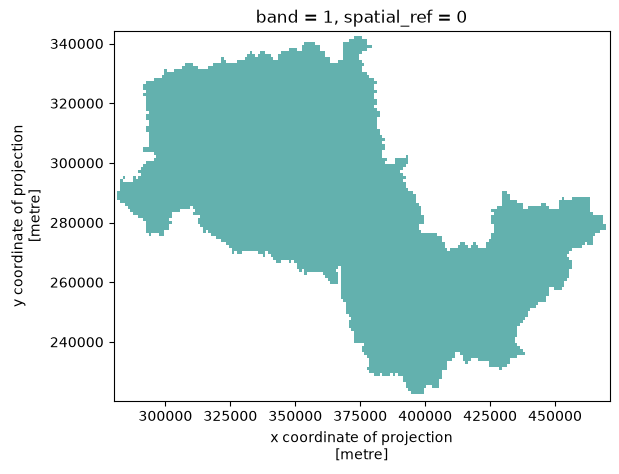

In [50]:
# Plot it out and check the mask looks correct
fig, ax = plt.subplots(1)
catchment_mask.plot(ax=ax, alpha=.7, add_colorbar=False)
ax.set_xlim(nrfa_shp.bounds['minx'][0]-CATCHMENT_BUFFER, nrfa_shp.bounds['maxx'][0]+CATCHMENT_BUFFER);
ax.set_ylim(nrfa_shp.bounds['miny'][0]-CATCHMENT_BUFFER, nrfa_shp.bounds['maxy'][0]+CATCHMENT_BUFFER);
plt.show()


### Mask rainfall based on catchment mask
Finally, we can do the magic part of masking out the Radar rainfall over that catchment using a simple multiplication (rainfall data times by mask).

In [51]:
def mask_region_rainfall(rainfall_data, region_mask):
    """
    Mask region by binary height raster
    """
    return rainfall_data * binarize_hght_clip(region_mask).data

In [52]:
# Mask rainfall based on catchment mask
catchment_masked_rainfall = mask_region_rainfall(catchment_radar_ds, catchment_mask)

In [69]:
hour_date_time_to_examine = "2026-07-02 01:00"

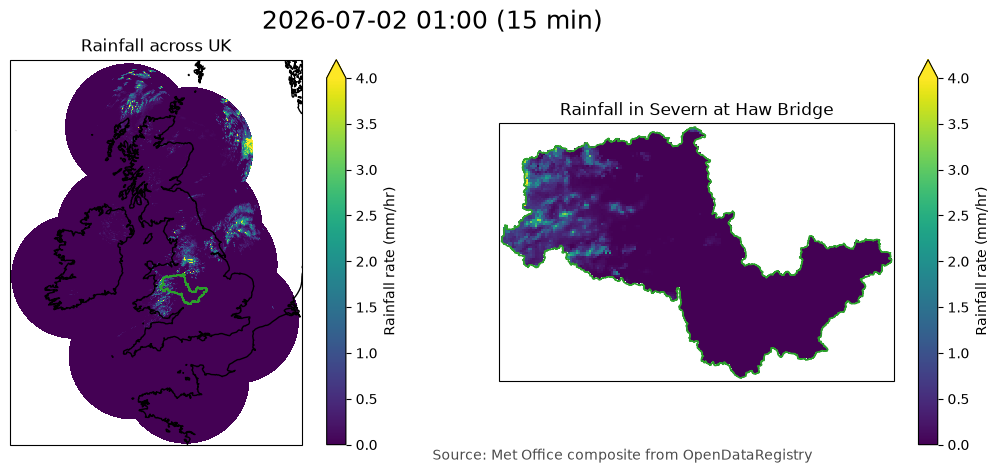

In [81]:
fig, axes = plt.subplots(1, 2, subplot_kw={'projection': bng}, figsize=(14, 5))
combined_radar_ds['data'].where(lambda data: data >= 0 ).sel(time=hour_date_time_to_examine).plot(
    ax=axes[0], vmax=4, cbar_kwargs={"label": "Rainfall rate (mm/hr)"}, transform=bng
)

catchment_masked_rainfall.sel(time=hour_date_time_to_examine)["data"].plot(
    ax=axes[1], vmax=4, cbar_kwargs={"label": "Rainfall rate (mm/hr)"}, transform=bng
)

for ax in axes:
    nrfa_shp.plot(ax=ax, facecolor="none", edgecolor="C2", transform=bng)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.coastlines()

plt.suptitle(f"{hour_date_time_to_examine} (15 min)", size=18)
axes[0].set_title("Rainfall across UK")
axes[1].set_title("Rainfall in Severn at Haw Bridge")
fig.text(s="Source: Met Office composite from OpenDataRegistry", x=.5, y=.08, c='k', alpha=.7)
# fig.savefig("../../figures/severn_catchment_subset_15min_aws.png", bbox_inches='tight', dpi=150)

### Calculate catchment average rainfall from radar data
Now that we have masked rainfall for the catchment, you may want to compute spatial and time averages of the radar field over the catchment. Below are examples of how to do that...

In [85]:
catchment_masked_rainfall_spatial_mean = catchment_masked_rainfall.mean(dim='time')
catchment_masked_rainfall_time_mean = catchment_masked_rainfall.mean(['x', 'y']).sortby('time')

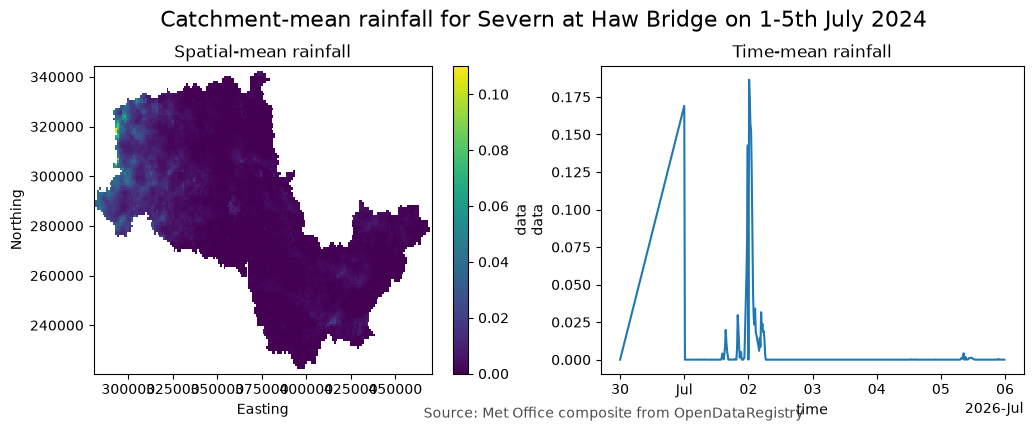

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
catchment_masked_rainfall_spatial_mean['data'].plot(ax=axes[0])
catchment_masked_rainfall_time_mean['data'].plot(ax=axes[1])
fig.suptitle("Catchment-mean rainfall for Severn at Haw Bridge on 1-5th July 2024", y=1.02, size=16)
axes[0].set_title("Spatial-mean rainfall")
axes[0].set_ylabel("Northing"); axes[0].set_xlabel("Easting"); 
axes[1].set_title("Time-mean rainfall")
fig.text(s="Source: Met Office composite from OpenDataRegistry", x=.4, y=.0, c='k', alpha=.7)

# fig.savefig("../../figures/catchment_mean_rainfall_aws.png", bbox_inches='tight', dpi=150)